# Defi EquiAlgo - modele corrige

## 1. Redefinition de la cible

`decision_octroi` est biaise : a cote R egale, le comite accorde nettement moins aux regions
eloignees. Il n'existe pas d'autre etiquette, et une heuristique inventee (ex. cote R seule)
serait elle-meme un parti pris non mesure.

On redefinit donc la cible **a partir des donnees du comite**, en ne retirant que l'effet de la region.

**Hypothese :** le comite est juste pour le groupe Centre. Le merite estime d'un candidat est la
probabilite d'octroi qu'il aurait eue s'il avait ete traite comme un candidat du Centre.

Methode (`cible.py`) : regression logistique de `decision_octroi` avec un indicateur `eloignee`
explicite, puis prediction avec `eloignee = 0`. `code_postal_3` est exclu, car il est determine par la
region et absorberait l'effet.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from fairlearn.postprocessing import ThresholdOptimizer

from analyse import evaluer_auc
from cible import (
    ajouter_eloignee, ajuster_modele_decision, coefficients,
    score_contrefactuel, octroi_top_k, octroi_par_tranche_r,
)

demandes = pd.read_csv('data/donnees_demandes.csv')
candidats = pd.read_csv('data/candidats_evaluation.csv')
groupe_hist = np.where(ajouter_eloignee(demandes)['eloignee'] == 1, 'Eloignee', 'Centre')
groupe_cand = np.where(ajouter_eloignee(candidats)['eloignee'] == 1, 'Eloignee', 'Centre')

### 1.1 Le modele de decision reproduit-il le comite ?

AUC sur un decoupage 70/30 identique a la baseline (RF : ~0.946). Le modele lineaire doit capter
la logique du comite aussi bien que le RF pour que le contrefactuel soit credible.

In [2]:
train, test = train_test_split(
    demandes, test_size=0.3, random_state=42, stratify=demandes['decision_octroi']
)
modele_valid = ajuster_modele_decision(train)
print(evaluer_auc(modele_valid, ajouter_eloignee(test), test['decision_octroi'],
                  groupes=groupe_hist[test.index]).round(4))

# Modele final, ajuste sur tout l'historique.
modele_decision = ajuster_modele_decision(demandes)
print()
print(coefficients(modele_decision).round(3))

global      0.9540
Centre      0.9530
Eloignee    0.9497
Name: auc, dtype: float64

num__cote_r_equivalent                     4.102
num__eloignee                             -1.072
num__heures_travail_semaine                0.750
num__revenu_familial_estime                0.749
cat__programme_etudes_Arts et lettres     -0.233
cat__programme_etudes_Sciences sociales   -0.220
cat__programme_etudes_Sciences            -0.192
cat__programme_etudes_Genie               -0.165
cat__programme_etudes_Sante               -0.153
num__distance_domicile_campus_km           0.128
num__premiere_generation_universitaire    -0.022
dtype: float64


In [3]:
# La penalite est-elle un simple decalage, ou les pentes different-elles selon le groupe ?
# (dans un groupe, `eloignee` est constant : son coefficient est nul)
for g in ['Centre', 'Eloignee']:
    c = coefficients(ajuster_modele_decision(demandes[groupe_hist == g]))
    print(f"{g:<9} cote R {c['num__cote_r_equivalent']:.3f}   revenu {c['num__revenu_familial_estime']:.3f}"
          f"   heures {c['num__heures_travail_semaine']:.3f}")

print()
print(demandes.groupby(groupe_hist)[['cote_r_equivalent', 'revenu_familial_estime',
                                     'heures_travail_semaine', 'distance_domicile_campus_km']].mean().round(1))

Centre    cote R 4.043   revenu 0.708   heures 0.624
Eloignee  cote R 4.064   revenu 0.734   heures 0.663

          cote_r_equivalent  revenu_familial_estime  heures_travail_semaine  \
Centre                 28.0                 76056.3                     9.0   
Eloignee               27.3                 56330.3                    13.0   

          distance_domicile_campus_km  
Centre                           19.8  
Eloignee                        221.5  


Les pentes sont quasi identiques d'un groupe a l'autre : le biais du comite est un **decalage
constant** applique aux regions eloignees, ce que le modele additif capture correctement.

Point d'attention : le revenu familial a un effet **positif** dans les deux groupes (les menages
plus aises obtiennent davantage). Ce n'est donc pas un proxy pur de la region, mais il penalise
indirectement les regions eloignees, dont le revenu moyen est plus faible. D'ou une variante qui
neutralise aussi le revenu (fixe a la mediane).

### 1.2 Effet sur l'historique : octroi a cote R egale

Taux d'octroi par tranche de cote R : comite, puis contrefactuel (top 40 %).

In [4]:
score_hist = score_contrefactuel(modele_decision, demandes)
octroi_hist = octroi_top_k(score_hist, taux=demandes['decision_octroi'].mean())

comparaison = pd.concat({
    'comite': octroi_par_tranche_r(demandes, demandes['decision_octroi']),
    'contrefactuel': octroi_par_tranche_r(demandes, octroi_hist),
}, axis=1)
print(comparaison.round(3))
print()
print('Taux par groupe, comite       :', pd.Series(demandes['decision_octroi'].values).groupby(groupe_hist).mean().round(3).to_dict())
print('Taux par groupe, contrefactuel:', pd.Series(octroi_hist).groupby(groupe_hist).mean().round(3).to_dict())

                  comite          contrefactuel         
                  Centre Eloignee        Centre Eloignee
cote_r_equivalent                                       
(0, 26]            0.020    0.005         0.001    0.001
(26, 27]           0.161    0.038         0.012    0.016
(27, 28]           0.316    0.100         0.065    0.157
(28, 29]           0.593    0.256         0.400    0.583
(29, 30]           0.849    0.568         0.883    0.943
(30, 32]           0.958    0.831         1.000    1.000
(32, 45]           0.998    0.986         1.000    1.000

Taux par groupe, comite       : {'Centre': 0.484, 'Eloignee': 0.273}
Taux par groupe, contrefactuel: {'Centre': 0.414, 'Eloignee': 0.378}


L'ecart global passe d'environ 21 points a environ 4 points ; le reste s'explique par la cote R
moyenne plus faible en region (27.3 contre 28.0).

A cote R egale, le contrefactuel favorise maintenant **legerement** les regions eloignees dans les
tranches 27 a 29. Ce n'est pas un artefact : le comite valorise les heures travaillees et la distance,
plus elevees en region (13 h contre 9 h, 222 km contre 20 km). Sa penalite regionale masquait ces
criteres. Le contrefactuel les applique tels quels ; savoir si ce sont des criteres de merite
legitimes est une question de gouvernance a trancher explicitement.

### 1.3 Triangulation sur les 4 000 candidats

L'etalon de reference est cache. On compare quatre cibles candidates ; si elles concordent
largement, le choix est robuste.

- **contrefactuel** : region neutralisee (cible retenue)
- **contrefactuel + revenu** : region et revenu neutralises
- **cote R seule** : heuristique la plus simple
- **RF + ThresholdOptimizer** : modele de base corrige par egalite des chances *mesuree contre
  `decision_octroi`* (comparateur ; budget non garanti)

In [5]:
cibles = {
    'contrefactuel': octroi_top_k(score_contrefactuel(modele_decision, candidats, reference=demandes)),
    'contrefactuel + revenu': octroi_top_k(score_contrefactuel(
        modele_decision, candidats, neutraliser=['revenu_familial_estime'], reference=demandes)),
    'cote R seule': octroi_top_k(candidats['cote_r_equivalent']),
}

# Comparateur : RF de base + ThresholdOptimizer (egalite des chances vs decision_octroi).
CATEGORIELLES_RF = ['programme_etudes', 'region_administrative', 'code_postal_3']
X_hist = pd.get_dummies(demandes.drop(columns=['id_candidat', 'decision_octroi']), columns=CATEGORIELLES_RF)
X_cand = pd.get_dummies(candidats.drop(columns=['id_candidat']), columns=CATEGORIELLES_RF
                        ).reindex(columns=X_hist.columns, fill_value=0)
rf = RandomForestClassifier(n_estimators=300, min_samples_leaf=20, random_state=42)
rf.fit(X_hist, demandes['decision_octroi'])
to = ThresholdOptimizer(estimator=rf, constraints='true_positive_rate_parity',
                        predict_method='predict_proba', prefit=True)
to.fit(X_hist, demandes['decision_octroi'], sensitive_features=groupe_hist)
cibles['RF + ThresholdOptimizer'] = to.predict(X_cand, sensitive_features=groupe_cand, random_state=42)

resume = pd.DataFrame({
    nom: {'taux global': d.mean(),
          'taux Centre': d[groupe_cand == 'Centre'].mean(),
          'taux Eloignee': d[groupe_cand == 'Eloignee'].mean()}
    for nom, d in cibles.items()
}).T
print(resume.round(3))

noms = list(cibles)
accord = pd.DataFrame([[(cibles[a] == cibles[b]).mean() for b in noms] for a in noms],
                      index=noms, columns=noms)
print()
print('Accord entre cibles (proportion de decisions identiques)')
print(accord.round(3))

                         taux global  taux Centre  taux Eloignee
contrefactuel                  0.400        0.411          0.385
contrefactuel + revenu         0.400        0.392          0.412
cote R seule                   0.400        0.428          0.359
RF + ThresholdOptimizer        0.388        0.455          0.289

Accord entre cibles (proportion de decisions identiques)
                         contrefactuel  contrefactuel + revenu  cote R seule  \
contrefactuel                    1.000                   0.940         0.928   
contrefactuel + revenu           0.940                   1.000         0.941   
cote R seule                     0.928                   0.941         1.000   
RF + ThresholdOptimizer          0.918                   0.904         0.950   

                         RF + ThresholdOptimizer  
contrefactuel                              0.918  
contrefactuel + revenu                     0.904  
cote R seule                               0.950  
RF + Thresho

Les trois cibles construites concordent sur environ 93 a 94 % des candidats : le choix de la
cible ne se joue que sur une bande etroite autour du seuil. Le comparateur ThresholdOptimizer garde un
grand ecart de taux d'octroi (environ 46 % contre 29 %) : egaliser la TPR par rapport a
`decision_octroi` revient a egaliser la fidelite a un comite biaise, sans corriger le biais.

### 1.4 Limites

- L'hypothese « le comite est juste pour le Centre » n'est pas verifiable sans l'etalon ; elle est
  explicite et documentee, ce qui vaut mieux qu'une regle implicite.
- Le contrefactuel conserve les autres poids du comite (revenu, heures). La variante
  « + revenu » mesure la sensibilite du resultat a ce choix.
- Le comparateur ThresholdOptimizer egalise la TPR **par rapport a `decision_octroi`**, donc par
  rapport a une etiquette biaisee : il sert de reference, pas de cible.

## 2. Front de Pareto equite / utilite

On evalue toutes les methodes sur le decoupage 70/30 de la baseline. Les modeles sont ajustes sur
`train` uniquement. Chaque methode accorde la bourse aux 40 % meilleurs scores de `test`, donc le
budget est identique partout et seules les priorites changent.

**References de merite.** L'etalon cache est inconnu ; on mesure contre quatre references :
`decision_octroi` (le comite) et les trois cibles de la section 1, recalculees sur `test` avec le
modele de `train`.

**Equite** : ecart d'egalite des chances, soit la TPR Centre moins la TPR Eloignee
(`analyse.ecart_egalite_chances`), qui est la metrique du scoreur. **Utilite** : exactitude par
rapport a la reference.

In [6]:
from analyse import ecart_egalite_chances

groupe_tr, groupe_te = groupe_hist[train.index], groupe_hist[test.index]
references = {
    'comite (decision_octroi)': test['decision_octroi'].to_numpy(),
    'contrefactuel': octroi_top_k(score_contrefactuel(modele_valid, test)),
    'contrefactuel + revenu': octroi_top_k(score_contrefactuel(
        modele_valid, test, neutraliser=['revenu_familial_estime'], reference=train)),
    'cote R seule': octroi_top_k(test['cote_r_equivalent']),
}

def evaluer(decisions):
    """Ecart d'egalite des chances et exactitude contre chaque reference."""
    return {
        (nom, mesure): valeur
        for nom, y in references.items()
        for mesure, valeur in [('ecart', ecart_egalite_chances(y, decisions, groupe_te)),
                               ('exactitude', (decisions == y).mean())]
    }

# Modele de production (RF), ajuste sur train, tel qu'utilise par la baseline.
X_tr = pd.get_dummies(train.drop(columns=['id_candidat', 'decision_octroi']), columns=CATEGORIELLES_RF)
X_te = pd.get_dummies(test.drop(columns=['id_candidat', 'decision_octroi']), columns=CATEGORIELLES_RF
                      ).reindex(columns=X_tr.columns, fill_value=0)
rf_tr = RandomForestClassifier(n_estimators=300, min_samples_leaf=20, random_state=42)
rf_tr.fit(X_tr, train['decision_octroi'])

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",20
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootst

### 2.1 Validation de la reference

Le scoreur annonce un ecart d'egalite des chances de **0.270** pour le modele de base, mesure
contre l'etalon cache. Si une reference reproduit ce chiffre, c'est un indice qu'elle approxime bien
l'etalon.

In [7]:
validation = pd.Series({nom: ecart_egalite_chances(y, rf_tr.predict(X_te), groupe_te)
                        for nom, y in references.items()}, name='ecart RF de base')
print(validation.round(3))
print('\nEcart annonce par le scoreur (etalon cache) : 0.270')

comite (decision_octroi)    0.063
contrefactuel               0.264
contrefactuel + revenu      0.333
cote R seule                0.238
Name: ecart RF de base, dtype: float64

Ecart annonce par le scoreur (etalon cache) : 0.270


Contre `decision_octroi`, le modele de base parait presque equitable (ecart d'environ 0.06) :
il reproduit fidelement le comite. Contre la reference contrefactuelle, son ecart est d'environ 0.26,
tres proche des 0.270 du scoreur. La cote R seule (environ 0.24) et la variante revenu (environ 0.33)
s'en eloignent davantage. C'est la meilleure justification empirique disponible pour la cible
contrefactuelle.

### 2.2 Balayage de la contrainte d'equite

Le parametre balaye est `retrait`, la fraction de la penalite regionale du comite retiree du score :
0 reproduit le comite, 1 donne le contrefactuel, et au-dela on surcorrige. Comme le modele est
lineaire en logit, chaque valeur correspond a un compromis precis.

Comparateurs : le RF de base (`predict`, comme en production) et le RF corrige par
`ThresholdOptimizer` (parite de TPR contre `decision_octroi`). Ses probabilites randomisees sont
classees pour respecter le budget. Faire varier `tol` ne produit que deux points distincts, d'ou un
point unique.

In [8]:
RETRAITS = [0, 0.25, 0.5, 0.75, 1.0, 1.25, 1.5]
balayage = pd.DataFrame({
    r: evaluer(octroi_top_k(score_contrefactuel(modele_valid, test, retrait=r))) for r in RETRAITS
}).T
balayage.index.name = 'retrait'

to_tr = ThresholdOptimizer(estimator=rf_tr, constraints='true_positive_rate_parity',
                           predict_method='predict_proba', prefit=True)
to_tr.fit(X_tr, train['decision_octroi'], sensitive_features=groupe_tr)
proba_to = to_tr._pmf_predict(X_te, sensitive_features=groupe_te)[:, 1]
# Departage les ex aequo de la randomisation par le score du RF.
octroi_to = octroi_top_k(proba_to + 1e-9 * rf_tr.predict_proba(X_te)[:, 1])

comparateurs = pd.DataFrame({
    'RF de base': evaluer(rf_tr.predict(X_te)),
    'RF + ThresholdOptimizer': evaluer(octroi_to),
}).T

pd.set_option('display.width', 200)
print(pd.concat([balayage, comparateurs]).round(3))

                        comite (decision_octroi)            contrefactuel            contrefactuel + revenu            cote R seule           
                                           ecart exactitude         ecart exactitude                  ecart exactitude        ecart exactitude
0.0                                        0.109      0.885         0.307      0.905                  0.355      0.880        0.256      0.907
0.25                                       0.050      0.884         0.232      0.928                  0.284      0.903        0.181      0.919
0.5                                       -0.030      0.876         0.146      0.955                  0.197      0.923        0.092      0.930
0.75                                      -0.106      0.873         0.062      0.981                  0.107      0.941        0.016      0.931
1.0                                       -0.151      0.863         0.000      1.000                  0.039      0.947       -0.041      0.928

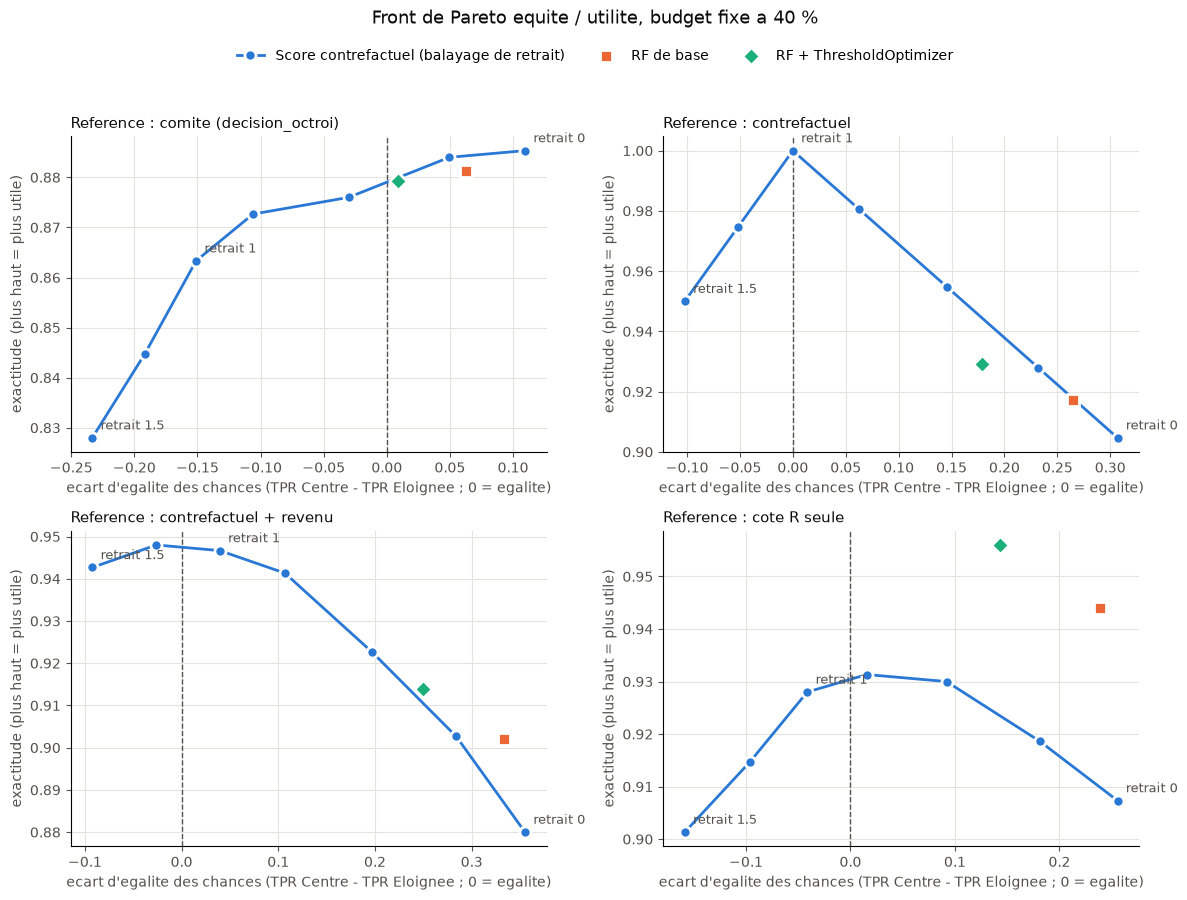

In [9]:
import matplotlib.pyplot as plt

# Palette categorielle de reference (slots 1-3, valides pour un nuage de points).
BLEU, ORANGE, VERT_EAU = '#2a78d6', '#eb6834', '#1baf7a'
ENCRE, ENCRE_SECONDAIRE, GRILLE = '#0b0b0b', '#52514e', '#e4e3df'

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
for ax, nom in zip(axes.flat, references):
    x, y = balayage[(nom, 'ecart')], balayage[(nom, 'exactitude')]
    ax.axvline(0, color=ENCRE_SECONDAIRE, lw=1, ls='--', zorder=1)
    ax.plot(x, y, '-o', color=BLEU, lw=2, ms=8, mec='white', mew=2,
            label='Score contrefactuel (balayage de retrait)', zorder=3)
    for r in [0, 1.0, 1.5]:
        ax.annotate(f'retrait {r:g}', (x[r], y[r]), xytext=(6, 6), textcoords='offset points',
                    fontsize=9, color=ENCRE_SECONDAIRE)
    for methode, couleur, forme in [('RF de base', ORANGE, 's'), ('RF + ThresholdOptimizer', VERT_EAU, 'D')]:
        ax.scatter(comparateurs.loc[methode, (nom, 'ecart')], comparateurs.loc[methode, (nom, 'exactitude')],
                   s=80, marker=forme, color=couleur, edgecolor='white', linewidth=2, zorder=4, label=methode)
    ax.set_title(f'Reference : {nom}', color=ENCRE, fontsize=11, loc='left')
    ax.set_xlabel('ecart d\'egalite des chances (TPR Centre - TPR Eloignee ; 0 = egalite)', color=ENCRE_SECONDAIRE)
    ax.set_ylabel('exactitude (plus haut = plus utile)', color=ENCRE_SECONDAIRE)
    ax.grid(color=GRILLE, lw=0.8)
    ax.set_axisbelow(True)
    for cote in ['top', 'right']:
        ax.spines[cote].set_visible(False)
    ax.tick_params(colors=ENCRE_SECONDAIRE)

poignees, etiquettes = axes.flat[0].get_legend_handles_labels()
fig.suptitle('Front de Pareto equite / utilite, budget fixe a 40 %', y=0.995, fontsize=13, color=ENCRE)
fig.legend(poignees, etiquettes, loc='upper center', bbox_to_anchor=(0.5, 0.965), ncol=3, frameon=False)
plt.tight_layout(rect=(0, 0, 1, 0.93))
plt.show()

**Lecture.** Le point ideal est sur la ligne pointillee (ecart nul), le plus haut possible.
- Contre `decision_octroi`, retirer la penalite fait perdre de l'exactitude : c'est le compromis
  « classique », mais il ne mesure que la fidelite au comite, pas le merite.
- Contre les deux references contrefactuelles, retirer la penalite ameliore **a la fois** l'equite
  et l'utilite jusqu'a `retrait` d'environ 1, puis la surcorrection degrade les deux. Le panneau
  « contrefactuel » est circulaire (`retrait = 1` y est parfait par construction) ; le panneau
  « + revenu » ne l'est pas, et donne un optimum proche (1 a 1.25).
- Contre la cote R seule, les deux RF sont plus exacts (0.94 a 0.96) mais gardent un ecart de 0.14 a
  0.24. Le balayage atteint un ecart quasi nul (0.016 a 0.75, -0.041 a 1) pour environ 0.93 d'exactitude.
- Le ThresholdOptimizer egalise la TPR contre une etiquette biaisee : il reduit l'ecart reel sans
  l'annuler (0.14 a 0.25 selon la reference de merite).

**Choix : `retrait = 1`.** C'est le point qui correspond a l'hypothese explicite (« traiter chacun
comme un candidat du Centre »), et non un point optimise contre une reference particuliere. Le meilleur
point est vers 0.75 contre la cote R seule et vers 1 a 1.25 contre la variante revenu : la valeur 1
reste proche de l'optimum pour chaque reference.

### 2.3 Soumission finale

Le modele de decision est ajuste sur les 10 000 dossiers historiques (section 1). Les 4 000
candidats sont classes par score contrefactuel, et on accorde la bourse exactement a 40 %.

In [10]:
predictions = octroi_top_k(score_contrefactuel(modele_decision, candidats, retrait=1.0), taux=0.40)

soumission = pd.DataFrame({'id_candidat': candidats['id_candidat'], 'decision_octroi': predictions})
assert len(soumission) == 4000 and soumission['id_candidat'].is_unique
assert set(soumission['decision_octroi']) <= {0, 1}
taux = soumission['decision_octroi'].mean()
assert 0.36 <= taux <= 0.44, f'Hors budget : {taux:.1%}'

soumission.to_csv('predictions.csv', index=False)
print(f'{len(soumission)} lignes ecrites dans predictions.csv, taux d\'octroi {taux:.1%}')
print(soumission.groupby(groupe_cand)['decision_octroi'].mean().round(3))

4000 lignes ecrites dans predictions.csv, taux d'octroi 40.0%
Centre      0.411
Eloignee    0.385
Name: decision_octroi, dtype: float64


## 3. Modele entraine sur la nouvelle cible

Le score contrefactuel de la section 1 est une **fonction deterministe des variables** : entrainer un
modele a predire `octroi_top_k(score_contrefactuel(...))` est circulaire (une regression logistique le
retrouve avec une AUC de 1.0). Il faut une cible d'entrainement qui contienne de l'information propre
a chaque dossier.

### 3.1 Cible individuelle

On garde la decision reelle du comite et on retire seulement la penalite regionale, dossier par dossier
(`cible.cible_individuelle`, raisonnement par abduction) :

- comite a accorde : le candidat aurait aussi obtenu la bourse sans la penalite, cible = 1 ;
- comite a refuse : cible = probabilite qu'il soit passe sans la penalite, (p_cf - p) / (1 - p) ;
- Centre : p_cf = p, la cible vaut exactement `decision_octroi` (hypothese de la section 1).

La cible est souple (entre 0 et 1). On l'apprend par classification ponderee : chaque dossier est
duplique, etiquette 1 avec poids `cible` et etiquette 0 avec poids `1 - cible`.

Le modele n'utilise **ni la region, ni le code postal** (`cible.VARIABLES_MODELE`) : la cible est deja
debiaisee, et un modele de production ne doit pas avoir besoin de l'attribut sensible.

In [11]:
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from cible import VARIABLES_MODELE, cible_individuelle, dupliquer_cible_souple

cible_tr = cible_individuelle(modele_valid, train)
cible_te = cible_individuelle(modele_valid, test)
print('Moyenne de la cible individuelle (train)')
print(pd.Series(cible_tr).groupby(groupe_tr).mean().round(3).to_dict(),
      ' contre decision_octroi :', train['decision_octroi'].groupby(groupe_tr).mean().round(3).to_dict())

Moyenne de la cible individuelle (train)
{'Centre': 0.484, 'Eloignee': 0.447}  contre decision_octroi : {'Centre': 0.484, 'Eloignee': 0.271}


### 3.2 Choix du modele

Trois familles, ajustees sur `train`, evaluees sur `test` :
- **AUC (cible individuelle)** : AUC ponderee contre la cible souple, la mesure d'ajustement ;
- **exactitude et ecart** contre les references de la section 2, apres octroi aux 40 % meilleurs.

In [12]:
NUM_MODELE = [c for c in VARIABLES_MODELE if c != 'programme_etudes']

def pipeline(estimateur):
    pretraitement = ColumnTransformer([
        ('num', StandardScaler(), NUM_MODELE),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), ['programme_etudes']),
    ])
    return make_pipeline(pretraitement, estimateur)

CANDIDATS_MODELES = {
    'Regression logistique': LogisticRegression(max_iter=3000),
    'Foret aleatoire': RandomForestClassifier(n_estimators=300, min_samples_leaf=20, random_state=42, n_jobs=-1),
    'Gradient boosting': HistGradientBoostingClassifier(learning_rate=0.05, max_iter=300,
                                                        min_samples_leaf=50, random_state=42),
}

def entrainer(estimateur, df, cible):
    X, y, poids = dupliquer_cible_souple(df[VARIABLES_MODELE], cible)
    modele = pipeline(estimateur)
    modele.fit(X, y, **{f'{modele.steps[-1][0]}__sample_weight': poids})
    return modele

n_te = len(test)
resultats, octrois_te = {}, {}
for nom, estimateur in CANDIDATS_MODELES.items():
    proba = entrainer(estimateur, train, cible_tr).predict_proba(test[VARIABLES_MODELE])[:, 1]
    octrois_te[nom] = octroi_top_k(proba)
    auc = roc_auc_score(np.r_[np.ones(n_te), np.zeros(n_te)], np.r_[proba, proba],
                        sample_weight=np.r_[cible_te, 1 - cible_te])
    resultats[nom] = {('cible individuelle', 'auc'): auc, **evaluer(octrois_te[nom])}

comparaison_modeles = pd.DataFrame(resultats).T
print(comparaison_modeles.round(3))

                      cible individuelle comite (decision_octroi)            contrefactuel            contrefactuel + revenu            cote R seule           
                                     auc                    ecart exactitude         ecart exactitude                  ecart exactitude        ecart exactitude
Regression logistique              0.954                   -0.150      0.864         0.002      0.996                  0.044      0.949       -0.040      0.931
Foret aleatoire                    0.950                   -0.125      0.867         0.011      0.973                  0.073      0.948       -0.029      0.943
Gradient boosting                  0.951                   -0.145      0.860        -0.018      0.967                  0.032      0.935       -0.051      0.921


La regression logistique est le meilleur modele : la logique du comite est essentiellement additive
en logit (section 1.1), et les modeles flexibles n'ajoutent que de la variance. Elle reste aussi la
plus simple a expliquer et a auditer (un coefficient par variable), ce qui compte pour la gouvernance.

In [13]:
modele_final = entrainer(LogisticRegression(max_iter=3000), train, cible_tr)
noms = modele_final[0].get_feature_names_out()
print('Coefficients standardises du modele entraine (sans region)')
print(pd.Series(modele_final[-1].coef_[0], index=noms).sort_values(key=abs, ascending=False).round(3))

Coefficients standardises du modele entraine (sans region)
num__cote_r_equivalent                     4.077
num__heures_travail_semaine                0.741
num__revenu_familial_estime                0.714
cat__programme_etudes_Arts et lettres     -0.132
num__distance_domicile_campus_km           0.105
num__premiere_generation_universitaire    -0.079
cat__programme_etudes_Sciences sociales   -0.068
cat__programme_etudes_Genie               -0.056
cat__programme_etudes_Sante                0.017
cat__programme_etudes_Sciences            -0.006
dtype: float64


### 3.3 Prediction des candidats

Le modele retenu est reajuste sur les 10 000 dossiers (cible calculee avec `modele_decision`), puis on
accorde la bourse aux 40 % meilleurs. On compare avec la soumission de la section 2.3 ; le fichier
`predictions.csv` n'est **pas** reecrit ici.

In [14]:
modele_cible = entrainer(LogisticRegression(max_iter=3000), demandes,
                         cible_individuelle(modele_decision, demandes))
predictions_modele = octroi_top_k(modele_cible.predict_proba(candidats[VARIABLES_MODELE])[:, 1], taux=0.40)

taux = predictions_modele.mean()
assert 0.36 <= taux <= 0.44, f'Hors budget : {taux:.1%}'
print(f'Taux d\'octroi : {taux:.1%}')
print(pd.Series(predictions_modele).groupby(groupe_cand).mean().round(3).to_dict())
print(f'Accord avec la soumission de la section 2.3 : {(predictions_modele == predictions).mean():.3f}')

Taux d'octroi : 40.0%
{'Centre': 0.41, 'Eloignee': 0.385}
Accord avec la soumission de la section 2.3 : 0.997
